# Training

## Imports

In [4]:
import pandas as pd
import numpy as np
import time
from src.lib.connectors import Connectors

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful")

Imports successful


## Load Processed Data

In [2]:
s3 = Connectors.connect_s3()

print("Loading processed data from S3...")
X_train = Connectors.load_from_s3(s3, 'processed-data/X_train.pkl')
y_train = Connectors.load_from_s3(s3, 'processed-data/y_train.pkl')
X_test  = Connectors.load_from_s3(s3, 'processed-data/X_test.pkl')
y_test  = Connectors.load_from_s3(s3, 'processed-data/y_test.pkl')

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Access key loaded: AKIA6...GJWR
Secret key loaded: ********************
Region: us-east-1
Bucket: card-fraud-detection-01

Verifying AWS connection...
Connected to AWS
Account ID: 977237814864
User: arn:aws:iam::977237814864:root
Loading processed data from S3...
Loading processed-data/X_train.pkl...


✓ Loaded: processed-data/X_train.pkl
Loading processed-data/y_train.pkl...


✓ Loaded: processed-data/y_train.pkl
Loading processed-data/X_test.pkl...


✓ Loaded: processed-data/X_test.pkl
Loading processed-data/y_test.pkl...


✓ Loaded: processed-data/y_test.pkl
X_train: (454902, 30)
y_train: (454902,)
X_test: (56962, 30)
y_test: (56962,)


## Training

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    print(f"{name} trained in {elapsed:.1f}s\n")

Training Logistic Regression...
Logistic Regression trained in 0.4s

Training Random Forest...
Random Forest trained in 17.3s

Training XGBoost...
XGBoost trained in 0.7s



In [8]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'auc_roc': roc_auc_score(y_test, y_prob),
        'auc_pr': average_precision_score(y_test, y_prob),
    }
    
    print(f"{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"AUC-ROC:  {results[name]['auc_roc']:.4f}")
    print(f"AUC-PR:   {results[name]['auc_pr']:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'])}\n")

Logistic Regression
AUC-ROC:  0.9698
AUC-PR:   0.7249

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Random Forest
AUC-ROC:  0.9688
AUC-PR:   0.8678

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


XGBoost
AUC-ROC:  0.9792
AUC-PR:   0.8774

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                     

XGBoost had the best AUC-PR which is what we are most concerned with. Becaue of the class imbalance we dont care about ROC, and aonly want precision and recall, so as not to include true negatives in our metrics.

## Visualizaton

### Confusion Matrix

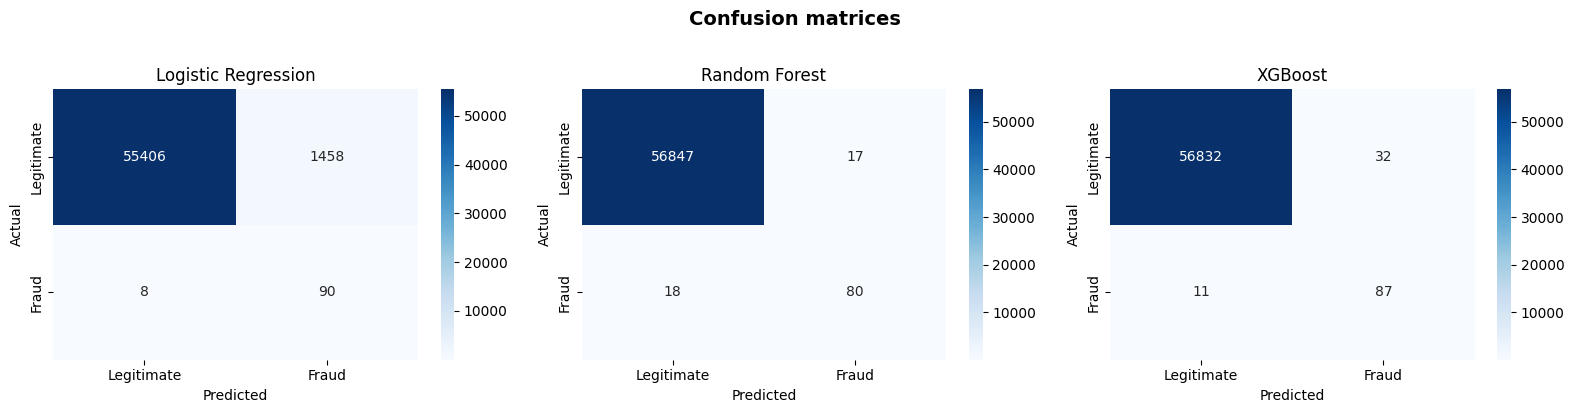

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud'],
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### PR Curves

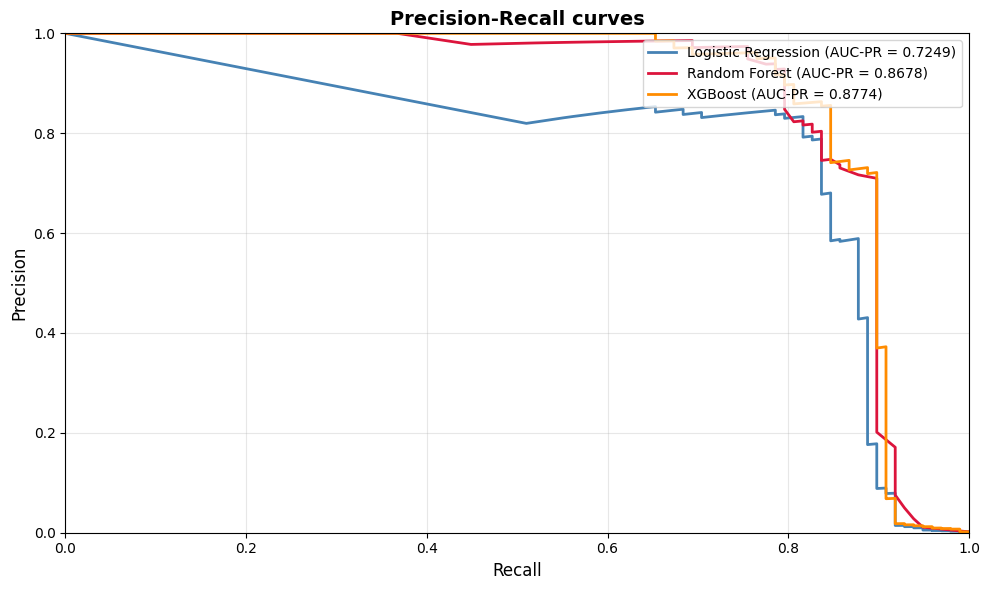

In [11]:

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue', 'crimson', 'darkorange']

for (name, model), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    auc_pr = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AUC-PR = {auc_pr:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall curves', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Logistic Regression performed far below XGBoost and Random Forest which were pretty similar in results, producing 80% recall for both of them.

### XGBoost Features

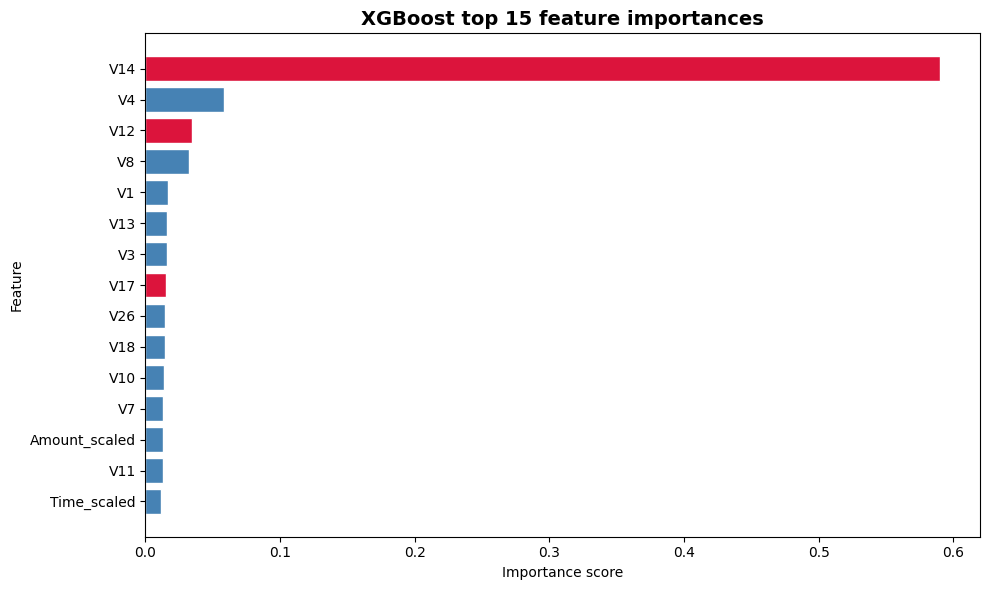

In [13]:
xgb_model = trained_models['XGBoost']

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['crimson' if f in ['V17', 'V14', 'V12'] else 'steelblue' for f in importance_df['feature']]
ax.barh(importance_df['feature'], importance_df['importance'], color=colors, edgecolor='white')

ax.set_title('XGBoost top 15 feature importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance score')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

Very heavy negative correlation in feature V14, significantly more than the next best positive correlation V4.